## HateXplain - 7 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous
* **Target 5:** Hate speech against african
* **Target 6:** Hate speech against asian
* **Target 7:** Hate speech against jewish

### Methods

* **MOLA**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers import AutoModel
from collections import Counter
from tqdm import tqdm
from datasets import load_dataset

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from ml_moo import moo, get_objectives, MooScalarization
from ml_moo.analysis.metrics import compute_hypervolume_progress
from ml_moo.analysis.visualization import plot_parallel_coordinates, plot_multiple_hypervolumes, plot_hypervolume
from ml_moo.scalarization.many_objs_hate_speech import HateSpeechScalarization

In [4]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [9]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        #self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        #self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        hate_women = 0
        hate_homosexual = 0
        hate_indigenous = 0
        hate_african = 0
        hate_asian = 0
        hate_jewish = 0

        for i in range(len(target_groups)):
            #print(target_groups[i])
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1
                if ('Indigenous' in target_groups[i]):
                    hate_indigenous = 1
                if ('African' in target_groups[i]):
                    hate_african = 1
                if ('Asian' in target_groups[i]):
                    hate_asian = 1
                if ('Jewish' in target_groups):
                    hate_jewish = 1

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
            "indigenous_hate": torch.tensor(hate_indigenous, dtype=torch.long),
            "african_hate": torch.tensor(hate_african, dtype=torch.long),
            "asian_hate": torch.tensor(hate_asian, dtype=torch.long),
            "jewish_hate": torch.tensor(hate_jewish, dtype=torch.long),    
        }

In [10]:
# Criar os datasets para treino, validação e teste
#train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#test_dataset = MultiTaskHateSpeechDataset(dataset["train"])
#
## DataLoaders
#batch_size = 8
#train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#valid_dataloader = DataLoader(val_dataset, batch_size=batch_size)
#test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [11]:
def extract_bert_embeddings(dataset, tokenizer_name="bert-base-uncased", max_length=128, batch_size=32, device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    model = AutoModel.from_pretrained(tokenizer_name).to(device)
    model.eval()

    texts = [" ".join(d["post_tokens"]) for d in dataset]

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[i:i+batch_size]
            encoding = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoding)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
            embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings, dim=0)  # Shape: (N, hidden_size)

from sklearn.decomposition import PCA

def apply_pca_and_save(embeddings: torch.Tensor, n_components=50, output_path="embeddings_pca.npy"):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings.numpy())
    np.save(output_path, reduced)
    return reduced

from collections import Counter
from torch.utils.data import Dataset

class PCAEmbeddingsDataset(Dataset):
    def __init__(self, pca_embeddings: np.ndarray, raw_dataset):
        self.embeddings = torch.tensor(pca_embeddings, dtype=torch.float)
        self.raw_dataset = raw_dataset
        

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        data = self.raw_dataset[idx]

        labels = data["annotators"]["label"]
        majority_label = Counter(labels).most_common(1)[0][0]
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        hate_women = 0
        hate_homosexual = 0
        hate_indigenous = 0
        hate_african = 0
        hate_asian = 0
        hate_jewish = 0
        
        for i in range(len(target_groups)):
            if label_hate == 1:
                if ('Women' in target_groups[i]):
                    hate_women = 1
                if ('Homosexual' in target_groups[i]):
                    hate_homosexual = 1
                if ('Indigenous' in target_groups[i]):
                    hate_indigenous = 1
                if ('African' in target_groups[i]):
                    hate_african = 1
                if ('Asian' in target_groups[i]):
                    hate_asian = 1
                if ('Jewish' in target_groups):
                    hate_jewish = 1

        return {
            "embedding": self.embeddings[idx],
            "label": torch.tensor(label_hate, dtype=torch.long),
            "women_hate": torch.tensor(hate_women, dtype=torch.long),
            "homosexual_hate": torch.tensor(hate_homosexual, dtype=torch.long),
            "indigenous_hate": torch.tensor(hate_indigenous, dtype=torch.long),
            "african_hate": torch.tensor(hate_african, dtype=torch.long),
            "asian_hate": torch.tensor(hate_asian, dtype=torch.long),
            "jewish_hate": torch.tensor(hate_jewish, dtype=torch.long),    
        }

# Suponha que você tenha carregado seu dataset JSON como `raw_dataset`

embeddings = extract_bert_embeddings(dataset["train"])
pca_embeddings = apply_pca_and_save(embeddings, n_components=50, output_path="embeddings_pca.npy")
#
## Agora use para treinar seu modelo
dataset_pca = PCAEmbeddingsDataset(pca_embeddings, dataset["train"])
train_dataloader = DataLoader(dataset_pca, batch_size=64, shuffle=True)


100%|██████████| 481/481 [00:50<00:00,  9.45it/s]


In [12]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 300,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}

## MOLA

16:42:11 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
16:42:11 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0
available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:03<00:00, 68.48it/s]


Epoch 1 - Average training loss: 0.1049


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:03<00:00, 68.18it/s]


...

Epoch 3/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 98.66it/s] 


Epoch 3 - Average training loss: 0.0870


Evaluating: 100%|██████████| 241/241 [00:02<00:00, 115.88it/s]


new solution added [0.58918835 0.355233   0.27835444 0.02278066 0.35576724 0.11326077
 0.00210282]
load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


18:11:26 | DEBUG | ml_moo | Calculated weights: [9.99997948e-01 2.40524328e-07 0.00000000e+00 0.00000000e+00
 5.84920523e-07 9.22088643e-07 3.04757804e-07]
18:11:26 | DEBUG | ml_moo | Importance: 1.199168157217656e-06
18:11:26 | DEBUG | ml_moo | Global lower bound (y*): [0.58862079 0.35406919 0.27236243 0.02275837 0.35466344 0.1063852
 0.00174082]
18:11:26 | DEBUG | ml_moo | Iteration 301
18:11:26 | DEBUG | ml_moo | Solutions list: [array([0.58918835, 0.355233  , 0.27835444, 0.02278066, 0.35576724,
       0.11326077, 0.00210282]), array([0.58912607, 0.35556797, 0.27824282, 0.02279566, 0.35501967,
       0.11289698, 0.00210427]), array([0.58897894, 0.35497066, 0.27891503, 0.02279524, 0.35528974,
       0.11366292, 0.00209689]), array([0.58905245, 0.35583906, 0.27931366, 0.02279404, 0.35533005,
       0.11288625, 0.0021015 ]), array([0.58893112, 0.35528416, 0.278757  , 0.02279712, 0.35532217,
       0.11331507, 0.00210374]), array([0.58862079, 0.35543258, 0.27875248, 0.02399112, 0.355324

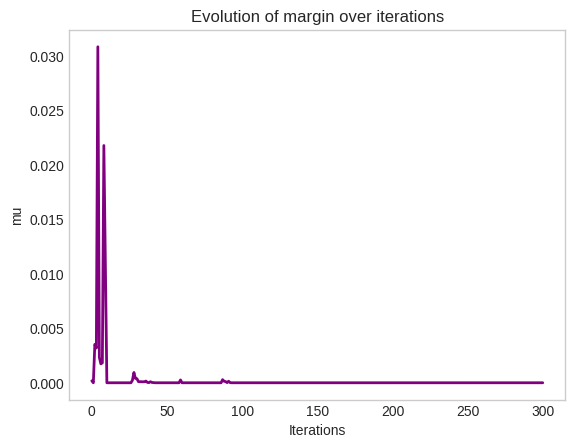

18:11:26 | INFO | ml_moo | Fit runtime: 5355.17 seconds


In [13]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [14]:
len(results['mola']['objectives'])

138

In [15]:
targets = ["General", "Women", "Homosexual", "Indigenous", "African", "Asian", "Jewish"]

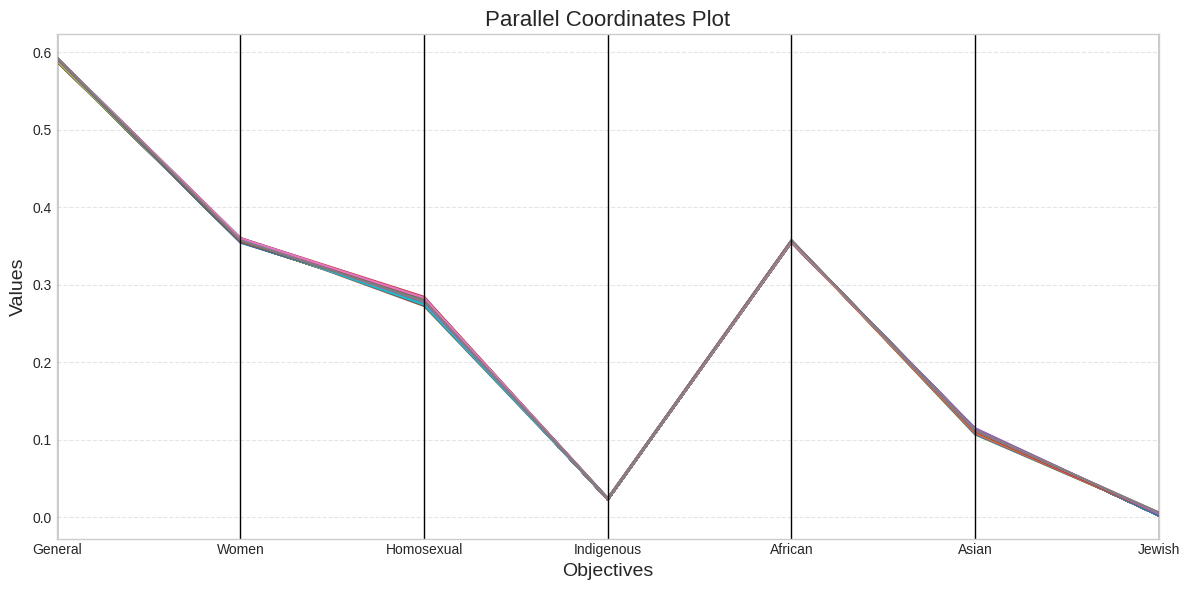

In [16]:
plot_parallel_coordinates(results['mola']['objectives'], labels=targets)

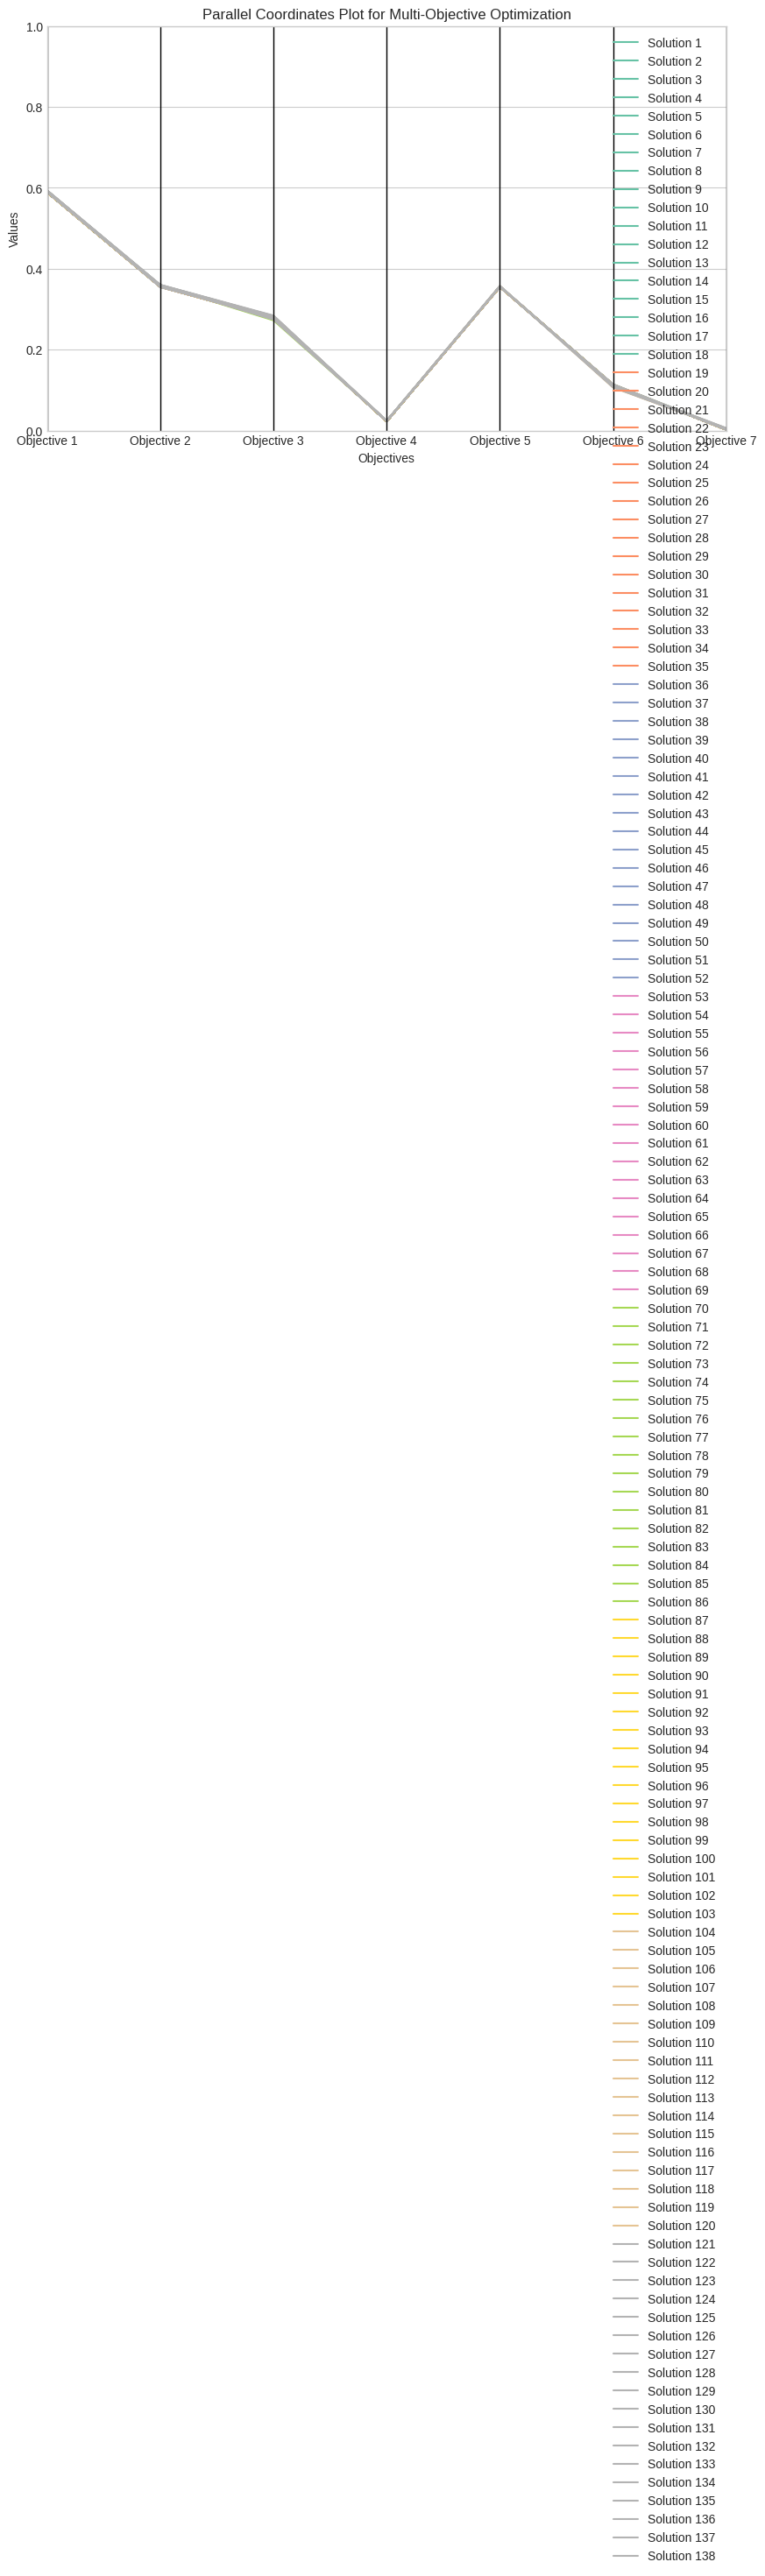

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Generate sample data for demonstration purposes
# Hypothetical objective values for a set of solutions
np.random.seed(42)
#num_solutions = 30
num_objectives = 7

# Creating a DataFrame with sample data
#data = np.random.rand(num_solutions, num_objectives)
df = pd.DataFrame(objs, columns=[f'Objective {i+1}' for i in range(num_objectives)])
df['Solution'] = [f'Solution {i+1}' for i in range(len(objs))]

# Plotting the Parallel Coordinates Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df, 'Solution', colormap=plt.get_cmap("Set2"))
plt.title('Parallel Coordinates Plot for Multi-Objective Optimization')
plt.xlabel('Objectives')
plt.ylabel('Values')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

In [18]:
#plot_parallel_coordinates(results['mola_grad']['objectives'], labels=targets, color="#FF5C8D")

## Mola + Gradiente

18:11:27 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 300, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:11:27 | DEBUG | ml_moo | Finding 1th individual minimum


device: cuda:0
available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 98.96it/s] 


Epoch 1 - Average training loss: 0.0991


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 99.34it/s] 


...

Epoch 3/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 102.68it/s]


Epoch 3 - Average training loss: 0.0875


Evaluating: 100%|██████████| 241/241 [00:02<00:00, 115.57it/s]


new solution added [0.58919786 0.35233069 0.27083579 0.02299786 0.35662146 0.1081832
 0.00251449]
solution dominated [0.58930562 0.35244092 0.27093362 0.02300151 0.3566218  0.10818758
 0.00251679]
load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


19:58:32 | DEBUG | ml_moo | Calculated weights: [9.99990639e-01 8.81145866e-07 0.00000000e+00 0.00000000e+00
 1.30825152e-06 6.19165511e-06 0.00000000e+00]
19:58:32 | DEBUG | ml_moo | Importance: 1.954776624235599e-06
19:58:32 | DEBUG | ml_moo | Global lower bound (y*): [0.58863056 0.3506807  0.27053643 0.02210661 0.35536208 0.10653909
 0.00164854]
19:58:32 | DEBUG | ml_moo | Iteration 301
19:58:32 | DEBUG | ml_moo | Solutions list: [array([0.58919786, 0.35233069, 0.27083579, 0.02299786, 0.35662146,
       0.1081832 , 0.00251449]), array([0.58883581, 0.35239042, 0.27085541, 0.0229796 , 0.35699195,
       0.10848599, 0.00251016]), array([0.58899442, 0.35242807, 0.27092401, 0.02300125, 0.35643679,
       0.10852011, 0.00251585]), array([0.58917763, 0.35244464, 0.27063905, 0.02297819, 0.35639344,
       0.10889863, 0.00251575]), array([0.58899745, 0.35224597, 0.27107436, 0.02300403, 0.35656753,
       0.10820929, 0.00249482]), array([0.58921976, 0.35224454, 0.2709879 , 0.02297566, 0.35649

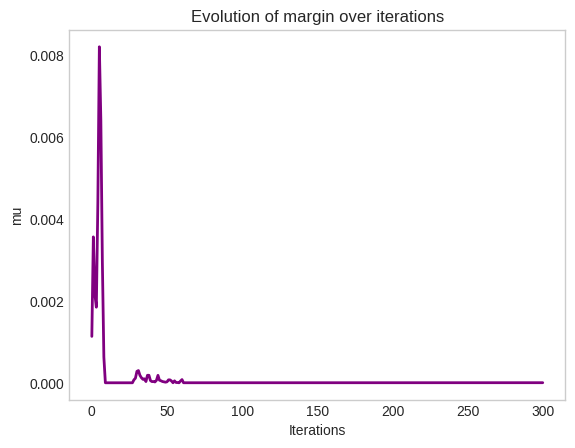

19:58:32 | INFO | ml_moo | Fit runtime: 6424.78 seconds


In [19]:
method = 'mola'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name, gradient=True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [20]:
len(results['mola_grad']['objectives'])

152

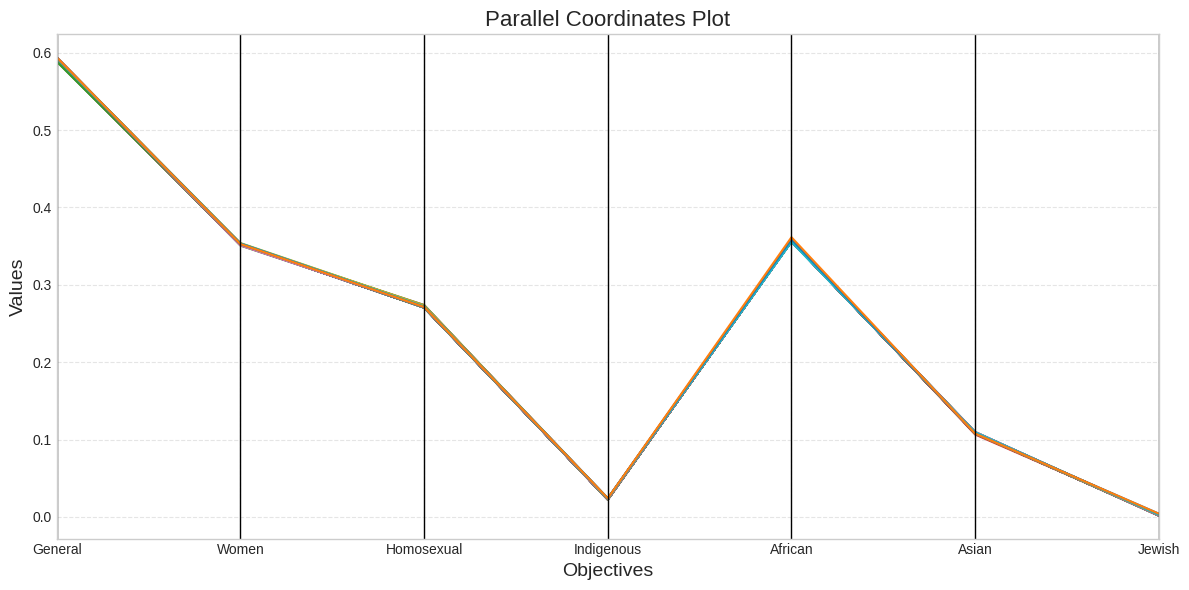

In [21]:
plot_parallel_coordinates(objs, labels=targets)

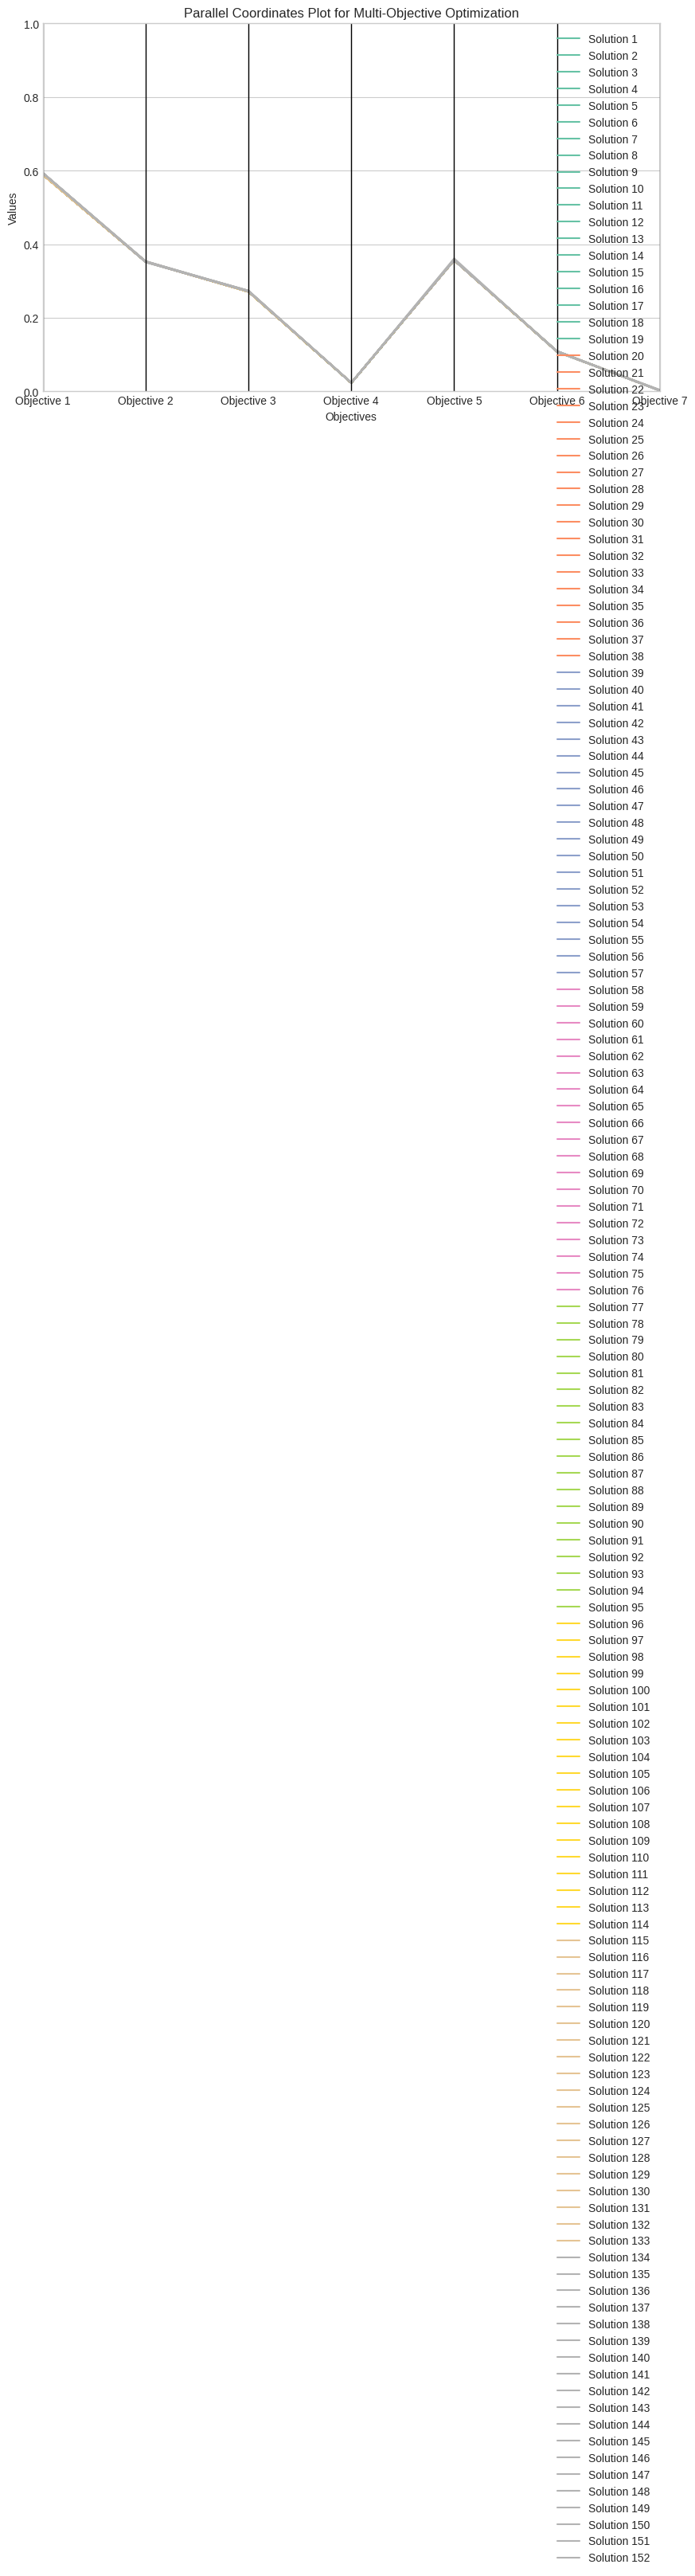

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Generate sample data for demonstration purposes
# Hypothetical objective values for a set of solutions
np.random.seed(42)
#num_solutions = 30
num_objectives = 7

# Creating a DataFrame with sample data
#data = np.random.rand(num_solutions, num_objectives)
df = pd.DataFrame(objs, columns=[f'Objective {i+1}' for i in range(num_objectives)])
df['Solution'] = [f'Solution {i+1}' for i in range(len(objs))]

# Plotting the Parallel Coordinates Plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df, 'Solution', colormap=plt.get_cmap("Set2"))
plt.title('Parallel Coordinates Plot for Multi-Objective Optimization')
plt.xlabel('Objectives')
plt.ylabel('Values')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

## Random Weight

In [23]:
method = 'random_weight'
w_scalar = HateSpeechScalarization(train_dataloader=train_dataloader, device=device, model_name=model_name)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

19:58:33 | WARNING | ml_moo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
19:58:33 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 300, 'norm': False}
19:58:33 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima


device: cuda:0
available: True


Epoch 1/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 101.98it/s]


Epoch 1 - Average training loss: 0.1009


Epoch 2/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 102.07it/s]


...

Epoch 2/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 97.95it/s] 


Epoch 2 - Average training loss: 0.0326


Epoch 3/3 - Training: 100%|██████████| 241/241 [00:02<00:00, 95.60it/s]


Epoch 3 - Average training loss: 0.0325


Evaluating: 100%|██████████| 241/241 [00:02<00:00, 112.99it/s]
20:47:07 | DEBUG | ml_moo.moo.random_weights | 300th solution


In [24]:
len(results['random_weight']['objectives'])

300

## Comparison between MOO methods

In [25]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

20:55:31 | WARNING | ml_moo | [Methods have different numbers of solutions: {152, 138, 300}


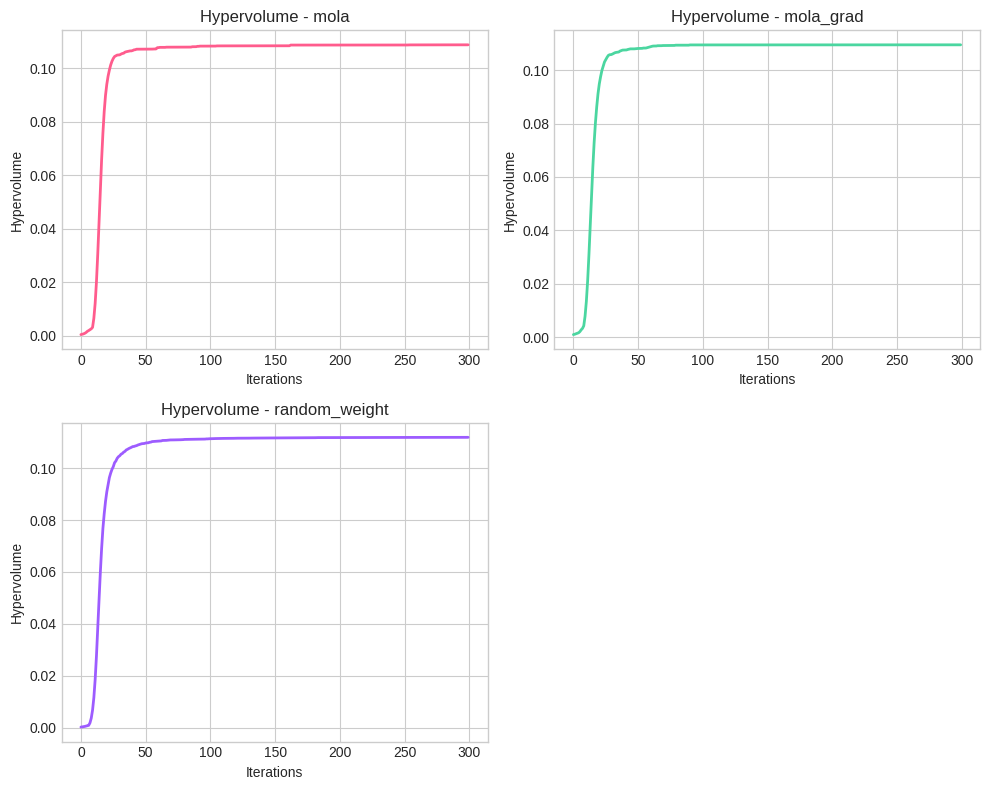

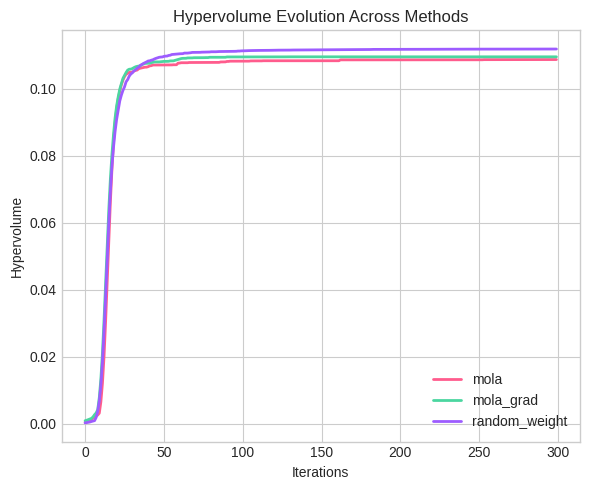

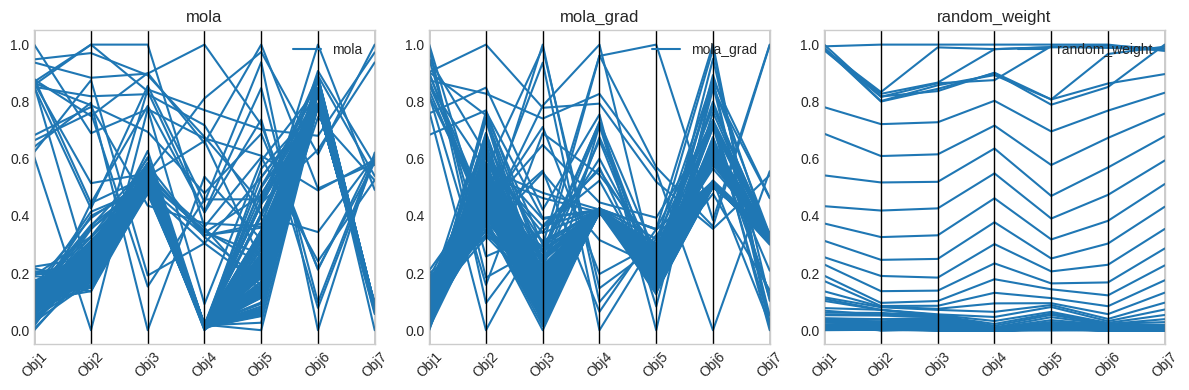

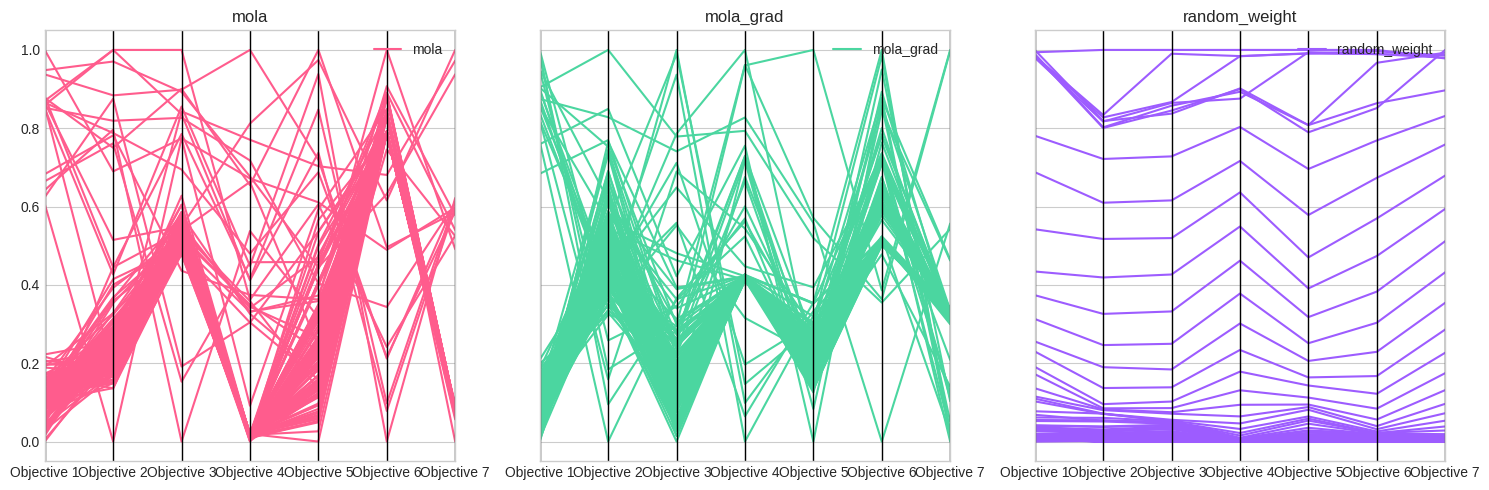

[Analyzer] Visualization complete.


: 

In [ ]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = targets

Analyzer.run_multiple(
                      pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = False, 
                      show_hypervolume = True,
                      show_parallel=True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      axis_label=axis_label
                      )